# Orthogonal Re-Basin - ResNet

Agnese Pallaria - matricola,1987001
---

## Struttura

| # | Sezione |
|---|---|
| 1| Dataset e Architettura |
| 2 | Training di due modelli indipendenti |
| 3 | CKA — quanto sono già simili funzionalmente? |
| 4 | I quattro metodi di allineamento ortogonale |
| 5 | Alignment error |
| 6 | ReLU misalignment e sign flip |
| 7 | Cycle-consistency |
| 8 | Applicazione Q ai pesi: cosa succede all'accuracy? |
| 9 | Loss barrier: LERP e SLERP |
| 10 | PCA dello spazio latente |
| 11 | Tabella Riassuntiva |

##1. Dataset e Architettura

INSTALL

In [2]:
# Installiamo la libreria PyTorch Lightning
# PyTorch Lightning è un framework che semplifica
# l'addestramento dei modelli PyTorch
!pip install pytorch-lightning -q

# Installiamo la libreria SciPy
# SciPy è utile per operazioni scientifiche e matematiche avanzate,
# come l'ottimizzazione e l'integrazione
!pip install scipy -q

# Installiamo la libreria scikit-learn
# Scikit-learn è una libreria fondamentale per machine learning,
# data preprocessing e modelli predittivi
!pip install scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 41.5 MB/s eta 0:00:00


IMPORT

In [3]:
# Importiamo PyTorch, la libreria principale per il deep learning
import torch
import torch.nn as nn  # Per costruire modelli neurali usando moduli predefiniti
import torch.nn.functional as F  # Per funzioni di attivazione e operazioni sui tensori
from torch.utils.data import DataLoader  # Per gestire dataset e batch in modo efficiente

# Importiamo torchvision per dataset standard e trasformazioni sulle immagini
import torchvision
import torchvision.transforms as transforms  # Per trasformazioni come normalizzazione e resizing

# Importiamo PyTorch Lightning, che semplifica il training dei modelli PyTorch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
# - ModelCheckpoint: salva il modello durante il training
# - EarlyStopping: ferma il training se la performance smette di migliorare

# Importiamo librerie utili per calcoli numerici e visualizzazione
import numpy as np  # Per operazioni numeriche avanzate su array
import matplotlib.pyplot as plt  # Per creare grafici e visualizzare immagini

# Importiamo strumenti avanzati da SciPy e scikit-learn
from sklearn.decomposition import PCA  # Per riduzione dimensionale con Principal Component Analysis
from scipy.linalg import svd as scipy_svd  # Per decomposizione ai valori singolari
from scipy.optimize import linear_sum_assignment  # Per risolvere problemi di assegnazione (Hungarian algorithm)

# Importiamo librerie standard per gestione file e copie di oggetti
import copy, os

In [4]:
os.makedirs("./experiments_resnet", exist_ok=True)
print(f"PyTorch {torch.__version__} | Lightning {pl.__version__}")

PyTorch 2.10.0+cpu | Lightning 2.6.1


DATASET

In [5]:
# Trasformazioni per ResNet
transform = transforms.ToTensor()

# Dataset CIFAR-10
train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_full  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# DataLoader
train_loader = DataLoader(train_full, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_full, batch_size=128, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:02<00:00, 74.3MB/s]


In [6]:
# Classi e info dataset
CLASSES = train_full.classes
print(f"Train: {len(train_full):,} immagini")
print(f"Test : {len(test_full):,} immagini")
print(f"Classi: {CLASSES}")

Train: 50,000 immagini
Test : 10,000 immagini
Classi: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


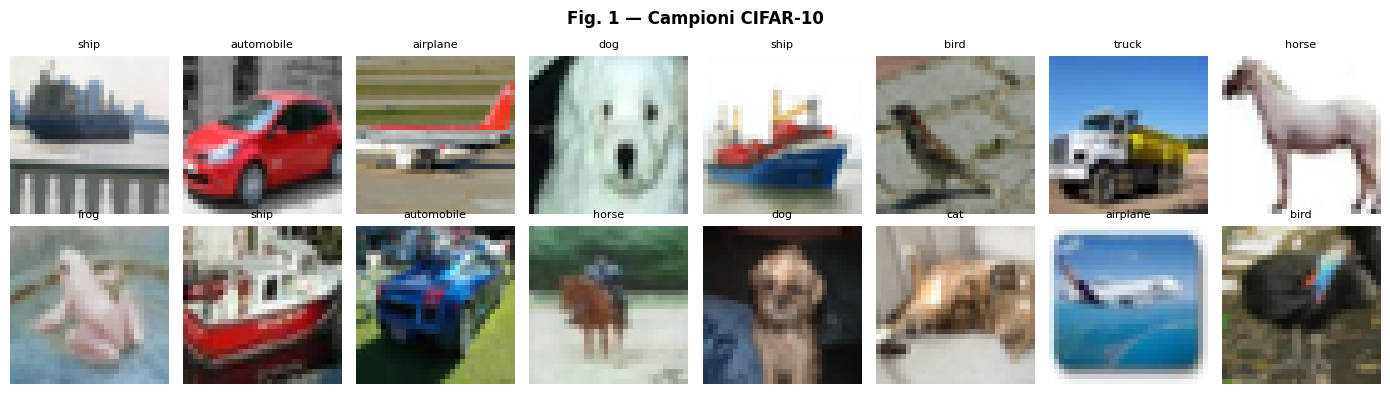

In [7]:
# Prendiamo un batch casuale di 16 immagini dal dataset di training
imgs, labels = next(iter(DataLoader(train_full, batch_size=16, shuffle=True)))

# Creiamo una griglia 2x8 per visualizzare le immagini
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

# Visualizziamo ogni immagine con la sua classe
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].permute(1, 2, 0).numpy().clip(0,1))  # Cambiamo ordine canali e limiti [0,1]
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis("off")

plt.suptitle("Fig. 1 — Campioni CIFAR-10", fontweight="bold")
plt.tight_layout()
plt.show()

ARCHITETTURA ResNet

In [8]:
import torch
import torch.nn as nn

class ResBlock(nn.Module):
    """Blocco residuo base: F(x) + x con skip connection."""
    def __init__(self, channels):
        super().__init__()
        # Il blocco residuo include due convoluzioni con BatchNorm e ReLU,
        # seguiti da una skip connection (l'aggiunta dell'input originale)
        self.block = nn.Sequential(
            nn.BatchNorm2d(channels), nn.ReLU(),  # Normalizzazione e ReLU
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),  # Conv2d 3x3
            nn.BatchNorm2d(channels), nn.ReLU(),  # Normalizzazione e ReLU
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),  # Conv2d 3x3
        )

    def forward(self, x):
        # Il risultato di questo blocco è l'input originale (x) sommato
        # con l'output del blocco (skip connection)
        return x + self.block(x)  # Skip connection


class SimpleResNet(nn.Module):
    """
    ResNet semplice per CIFAR-10.
    3 blocchi residui + un layer fully-connected latente (256-dim).
    Progettata per essere veloce su CPU mantenendo la struttura residua.
    """
    def __init__(self):
        super().__init__()
        # Stem: 3→32 canali: convoluzione iniziale seguita da BatchNorm e ReLU
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),  # Convoluzione 3x3 con 32 canali
            nn.BatchNorm2d(32), nn.ReLU()  # Normalizzazione e ReLU
        )

        # Primo blocco residuo: riduzione della dimensione spaziale (32→16)
        self.layer1 = nn.Sequential(ResBlock(32), nn.AvgPool2d(2))  # ResBlock + Average Pooling

        # Secondo blocco residuo: proiezione dei canali da 32 a 64 (32→64)
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, 1, bias=False),  # Convoluzione 1x1 per cambiare il numero di canali
            ResBlock(64), nn.AvgPool2d(2)      # ResBlock + Average Pooling (16→8)
        )

        # Terzo blocco residuo: proiezione dei canali da 64 a 128 (64→128)
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, 1, bias=False),  # Convoluzione 1x1 per cambiare il numero di canali
            ResBlock(128), nn.AvgPool2d(2)     # ResBlock + Average Pooling (8→4)
        )

        # Pooling adattivo (riduce a 128x1x1)
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Layer fully connected latente (256 dimensioni)
        self.fc_latent = nn.Linear(128, 256)

        # Layer finale di output (10 classi per CIFAR-10)
        self.fc_out = nn.Linear(256, 10)

        # ReLU per il layer latente
        self.relu = nn.ReLU()

    def forward(self, x):
        # Passaggio attraverso lo stem
        x = self.stem(x)
        # Passaggio attraverso i 3 blocchi residui
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        # Pooling finale e flattening
        x = self.pool(x).view(x.size(0), -1)
        # Passaggio attraverso il layer latente con ReLU
        x = self.relu(self.fc_latent(x))
        # Output finale
        return self.fc_out(x)

    def get_latent(self, x):
        """Attivazioni POST-ReLU di fc_latent — spazio 256-dim."""
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.relu(self.fc_latent(x))

    def get_pre_relu(self, x):
        """Attivazioni PRE-ReLU di fc_latent — per il sign flip."""
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc_latent(x)

# Test del modello
dummy = torch.randn(4, 3, 32, 32)  # Creazione di un batch di input fittizio
net_t = SimpleResNet()  # Creazione del modello

# Stampa delle dimensioni di output e dei parametri
print("SimpleResNet CIFAR-10:")
print(f"  Output   : {net_t(dummy).shape}")
print(f"  Latent   : {net_t.get_latent(dummy).shape}  ← stesso spazio di LeNet (256-dim)")
print(f"  Params   : {sum(p.numel() for p in net_t.parameters()):,}")

SimpleResNet CIFAR-10:
  Output   : torch.Size([4, 10])
  Latent   : torch.Size([4, 256])  ← stesso spazio di LeNet (256-dim)
  Params   : 434,730


In [9]:
print("256 neuroni come LeNet: il confronto tra le due architetture")
print("sarà diretto — stessa dimensione dello spazio latente.")

256 neuroni come LeNet: il confronto tra le due architetture
sarà diretto — stessa dimensione dello spazio latente.


##2. Training di due modelli indipendenti

TRAINING

In [10]:
# ResNetModule è una classe che estende pl.LightningModule per semplificare l'addestramento di un modello ResNet.
# In questa classe, definiremo il modello, la funzione di perdita e la configurazione degli ottimizzatori per l'addestramento.
class ResNetModule(pl.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.model     = SimpleResNet()  # Modello ResNet definito precedentemente
        self.lr        = lr  # Tasso di apprendimento
        self.criterion = nn.CrossEntropyLoss()  # Funzione di perdita per la classificazione multi-classe
        self.save_hyperparameters()  # Salva i parametri per una facile gestione del modello

    def forward(self, x):
        return self.model(x)

    def get_latent(self, x):
        return self.model.get_latent(x)

    def get_pre_relu(self, x):
        return self.model.get_pre_relu(x)

    # training_step calcola la loss durante l'addestramento
    def training_step(self, batch, _):
        imgs, labels = batch
        loss = self.criterion(self(imgs), labels)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    # validation_step calcola la loss e l'accuratezza sui dati di validazione
    def validation_step(self, batch, _):
        imgs, labels = batch
        out  = self(imgs)
        loss = self.criterion(out, labels)
        acc  = (out.argmax(1) == labels).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc",  acc,  prog_bar=True)

    # configure_optimizers imposta l'ottimizzatore e lo scheduler per il learning rate
    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=1e-3)  # Ottimizzatore Adam
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)  # Cosine Annealing Scheduler
        return [opt], [sch]  # Restituisce l'ottimizzatore e il learning rate scheduler

# Funzione di addestramento per il modello ResNet, gestisce i semini casuali, il salvataggio dei checkpoint e early stopping
def train_resnet(seed, name):
    print(f"\nTraining {name} — seed={seed}")
    torch.manual_seed(seed)  # Imposta il seme per la riproducibilità
    ckpt = ModelCheckpoint(
        dirpath="./experiments_resnet",  # Dove salvare i checkpoint
        filename=name,  # Nome del file di checkpoint
        monitor="val_acc",  # Monitora l'accuratezza di validazione
        mode="max",  # Salva il modello con la migliore accuratezza
        save_top_k=1  # Salva solo il miglior modello
    )
    es = EarlyStopping(monitor="val_acc", patience=6, mode="max")  # Early stopping per fermare l'addestramento
    trainer = pl.Trainer(
        max_epochs=15,  # Numero massimo di epoche
        callbacks=[ckpt, es],  # Usa i callback per il salvataggio e early stopping
        enable_progress_bar=True,  # Abilita la barra di progresso
        logger=False,  # Disabilita il logging
        accelerator="cpu"  # Usa la CPU (puoi sostituire con "gpu" se hai una GPU disponibile)
    )
    module = ResNetModule()  # Crea l'oggetto del modello
    trainer.fit(module, train_loader, test_loader)  # Avvia l'addestramento
    best = ResNetModule.load_from_checkpoint(ckpt.best_model_path)  # Carica il miglior modello
    print(f"  Best val_acc: {ckpt.best_model_score.item():.4f}")  # Mostra la migliore accuratezza di validazione
    return best  # Restituisce il modello con la miglior performance

In [11]:
module_A2 = train_resnet(seed=42, name="resnet_A")
net_A2    = module_A2.model


Training resnet_A — seed=42


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ SimpleResNet     │  434 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 434 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 434 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 42                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


  Best val_acc: 0.8331


In [12]:
module_B2 = train_resnet(seed=99, name="resnet_B")
net_B2    = module_B2.model

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Training resnet_B — seed=99


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/experiments_resnet exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ SimpleResNet     │  434 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 434 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 434 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 42                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


  Best val_acc: 0.8360


In [13]:
# @torch.no_grad() disabilita il calcolo del gradiente durante la valutazione per risparmiare memoria e calcoli
# La funzione `evaluate` calcola la loss media e l'accuratezza del modello sui dati forniti tramite un DataLoader.
@torch.no_grad()
def evaluate(model, loader):
    model.eval()  # Imposta il modello in modalità valutazione
    crit = nn.CrossEntropyLoss()  # Funzione di perdita per la classificazione multi-classe
    tot_loss, correct, n = 0., 0, 0  # Inizializza le variabili per la loss e l'accuratezza
    for imgs, labels in loader:  # Ciclo su tutte le immagini nel DataLoader
        out = model(imgs)  # Passa le immagini attraverso il modello
        tot_loss += crit(out, labels).item() * imgs.size(0)  # Somma la loss
        correct += (out.argmax(1) == labels).sum().item()  # Conta le predizioni corrette
        n += imgs.size(0)  # Incrementa il numero di immagini processate
    return tot_loss / n, correct / n  # Restituisce la loss media e l'accuratezza

# Esegui la valutazione per i modelli A e B
loss_A2, acc_A2 = evaluate(net_A2, test_loader)  # Valutazione del modello A
loss_B2, acc_B2 = evaluate(net_B2, test_loader)  # Valutazione del modello B

# Stampa i risultati di valutazione per i modelli A e B
print("=" * 45)  # Linea di separazione
print(f"  ResNet A (seed=42): acc={acc_A2:.4f}  loss={loss_A2:.4f}")  # Accuratezza e loss del modello A
print(f"  ResNet B (seed=99): acc={acc_B2:.4f}  loss={loss_B2:.4f}")  # Accuratezza e loss del modello B
print(f"  Gap accuracy      : {abs(acc_A2-acc_B2):.4f}")  # Calcolo della differenza di accuratezza tra i due modelli

# Calcola la correlazione tra i pesi del layer latente (fc_latent) dei due modelli
w_corr2 = np.corrcoef(
    net_A2.fc_latent.weight.data.numpy().flatten(),  # Pesos del modello A
    net_B2.fc_latent.weight.data.numpy().flatten()   # Pesos del modello B
)[0, 1]  # Correlazione tra i pesi dei layer latenti
print(f"  Correlazione pesi fc_latent: {w_corr2:.4f}")  # Stampa della correlazione tra i pesi

print("=" * 45)  # Linea di separazione

  ResNet A (seed=42): acc=0.8331  loss=0.5426
  ResNet B (seed=99): acc=0.8360  loss=0.5356
  Gap accuracy      : 0.0029
  Correlazione pesi fc_latent: -0.0074


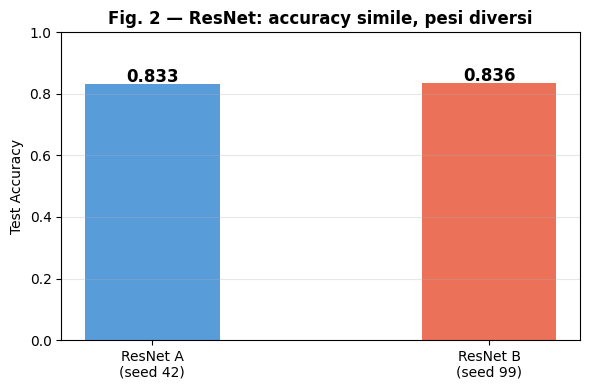

In [14]:
# Crea una figura e un'area di disegno con una dimensione di 6x4 pollici
fig, ax = plt.subplots(figsize=(6,4))

# Crea un grafico a barre per confrontare le accuratezze dei due modelli (ResNet A e ResNet B)
bars = ax.bar(["ResNet A\n(seed 42)", "ResNet B\n(seed 99)"],  # Etichette per le barre
              [acc_A2, acc_B2],  # Valori dell'accuratezza da visualizzare
              color=["#3B8BD4","#E8593C"],  # Colori delle barre (blu e arancione)
              alpha=0.85,  # Trasparenza delle barre
              width=0.4)  # Larghezza delle barre

# Aggiungi il valore dell'accuratezza sopra ogni barra
for b, v in zip(bars, [acc_A2, acc_B2]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,  # Posizione del testo
            f"{v:.3f}",  # Mostra il valore dell'accuratezza con 3 decimali
            ha="center", fontweight="bold", fontsize=12)  # Allineamento del testo e stile

# Imposta i limiti dell'asse y per garantire che tutte le barre siano visibili
ax.set_ylim(0, 1)

# Aggiungi etichetta all'asse y (accuratezza)
ax.set_ylabel("Test Accuracy")

# Aggiungi un titolo al grafico
ax.set_title("Fig. 2 — ResNet: accuracy simile, pesi diversi", fontweight="bold")

# Abilita la griglia sull'asse y per migliorare la leggibilità dei valori
ax.grid(True, axis="y", alpha=0.3)

# Ottimizza il layout del grafico per evitare sovrapposizioni
plt.tight_layout()

# Mostra il grafico
plt.show()

In [15]:
# Messaggio finale per il confronto tra ResNet A e ResNet B
print(f"\nStesso pattern di LeNet: accuracy simile ({acc_A2:.3f} vs {acc_B2:.3f})")
print(f"ma correlazione pesi quasi zero ({w_corr2:.4f}).")
# La bassa correlazione tra i pesi suggerisce che anche per ResNet esiste il problema di allineamento.
print("Conferma che il problema di allineamento esiste anche per ResNet.")


Stesso pattern di LeNet: accuracy simile (0.833 vs 0.836)
ma correlazione pesi quasi zero (-0.0074).
Conferma che il problema di allineamento esiste anche per ResNet.


##3. CKA layer-by-layer

In [16]:
# Funzione per calcolare il Centered Kernel Alignment (CKA) tra due matrici X e Y
# CKA è una misura di similarità che valuta quanto le due rappresentazioni siano simili
def linear_cka(X, Y):
    # Centra i dati sottraendo la media su ogni colonna (funzione di attivazione centrata)
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)

    # Calcola la matrice HSIC (Hilbert-Schmidt Independence Criterion) tra X e Y
    hsic = np.linalg.norm(X.T @ Y, "fro") ** 2  # Frobenius norm (norma matriciale) del prodotto tra X e Y

    # Calcola le norme Frobenius di X e Y
    normX = np.linalg.norm(X.T @ X, "fro")
    normY = np.linalg.norm(Y.T @ Y, "fro")

    # Restituisce il valore CKA (normalizzato tra 0 e 1) con un piccolo epsilon per stabilità numerica
    return hsic / (normX * normY + 1e-8)

# Funzione per ottenere le attivazioni (feature maps) di uno specifico layer di un modello durante la valutazione
# Per ogni batch nel DataLoader, la funzione registra le attivazioni del layer e le restituisce come un array numpy
def get_hook_acts(model, loader, layer):
    acts = []  # Lista per memorizzare le attivazioni
    # Registra un hook per il layer, in modo che ogni volta che il layer fa il forward pass, le attivazioni siano memorizzate
    h = layer.register_forward_hook(lambda m, i, o: acts.append(o.detach().cpu()))

    # Imposta il modello in modalità di valutazione e disabilita il calcolo del gradiente
    model.eval()
    with torch.no_grad():
        for imgs, _ in loader:  # Itera attraverso il DataLoader
            model(imgs)  # Passa le immagini attraverso il modello
    h.remove()  # Rimuovi l'hook dopo aver raccolto le attivazioni

    # Concatena tutte le attivazioni raccolte in un unico tensore e le converte in un array numpy
    out = torch.cat(acts, dim=0)
    return out.view(out.size(0), -1).numpy()  # Appiattisce le attivazioni in un array 2D

# Elenco di coppie di layer da confrontare per i modelli ResNet A e B
# In ogni coppia, confrontiamo le attivazioni degli stessi layer nei due modelli
layer_pairs2 = [
    ("stem",       net_A2.stem[-1],       net_B2.stem[-1]),  # Primo layer convoluzionale
    ("layer1",     net_A2.layer1[0].block[-1], net_B2.layer1[0].block[-1]),  # Primo blocco residuo
    ("layer2",     net_A2.layer2[1].block[-1], net_B2.layer2[1].block[-1]),  # Secondo blocco residuo
    ("layer3",     net_A2.layer3[1].block[-1], net_B2.layer3[1].block[-1]),  # Terzo blocco residuo
    ("fc_latent",  net_A2.fc_latent,      net_B2.fc_latent),  # Spazio latente (fully connected)
    ("fc_out",     net_A2.fc_out,         net_B2.fc_out),  # Output finale (fully connected)
]

# Inizia il calcolo del CKA layer-by-layer per i modelli ResNet A e B
print("Calcolo CKA layer-by-layer ResNet...")
cka_scores2 = {}  # Dizionario per memorizzare i risultati CKA per ogni layer
print("=" * 50)
print(f"  {'Layer':<12} {'CKA':>8}  {'Note'}")  # Intestazioni della tabella dei risultati
print("=" * 50)

# Calcola e stampa il CKA per ogni coppia di layer
for name, lA, lB in layer_pairs2:
    s = linear_cka(  # Calcola la similarità CKA tra le attivazioni di ciascun layer nei modelli A e B
        get_hook_acts(net_A2, test_loader, lA),
        get_hook_acts(net_B2, test_loader, lB))

    cka_scores2[name] = s  # Memorizza il risultato del CKA nel dizionario
    # Determina la qualità della similarità CKA (alta, media, bassa) in base al valore di CKA
    note = "alta" if s > 0.7 else ("media" if s > 0.4 else "bassa")
    # Stampa i risultati per ciascun layer
    print(f"  {name:<12} {s:>8.4f}  similarità {note}")

print("=" * 50)  # Linea di separazione finale

Calcolo CKA layer-by-layer ResNet...
  Layer             CKA  Note
  stem           0.9761  similarità alta
  layer1         0.8404  similarità alta
  layer2         0.8507  similarità alta
  layer3         0.8790  similarità alta
  fc_latent      0.8833  similarità alta
  fc_out         0.9250  similarità alta


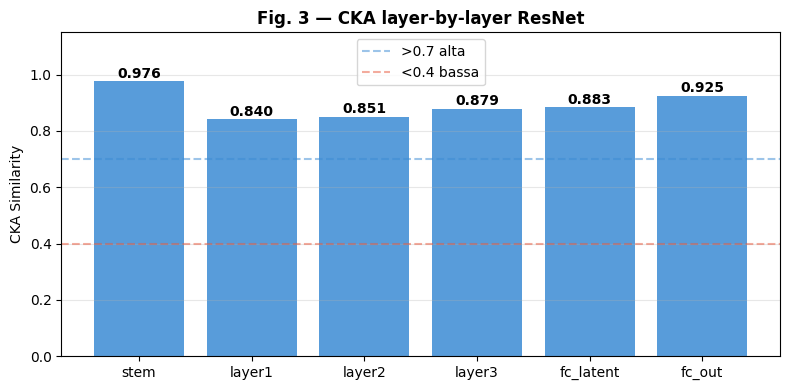

In [17]:
# Crea un grafico a barre per visualizzare i risultati del CKA per ciascun layer
# Le barre sono colorate in base al valore del CKA: blu per valori > 0.7, arancione per valori > 0.4 e rosso per valori < 0.4
fig, ax = plt.subplots(figsize=(8,4))  # Imposta la figura con una larghezza di 8 pollici e altezza di 4
cols_cka2 = ["#3B8BD4" if v>0.7 else "#F2A623" if v>0.4 else "#E8593C"
             for v in cka_scores2.values()]  # Colori per ogni barra in base al valore del CKA

# Crea il grafico a barre con i colori definiti
bars = ax.bar(list(cka_scores2.keys()), list(cka_scores2.values()),
              color=cols_cka2, alpha=0.85)  # Opacità delle barre impostata a 0.85

# Aggiungi i valori numerici sopra ogni barra
for b, v in zip(bars, cka_scores2.values()):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012,
            f"{v:.3f}", ha="center", fontweight="bold")  # Posiziona il testo sopra ogni barra

# Aggiungi linee orizzontali per i valori di CKA alta (>0.7) e bassa (<0.4)
ax.axhline(0.7, color="#3B8BD4", ls="--", alpha=0.5, label=">0.7 alta")  # Linea tratteggiata per CKA > 0.7
ax.axhline(0.4, color="#E8593C", ls="--", alpha=0.5, label="<0.4 bassa")  # Linea tratteggiata per CKA < 0.4

# Imposta i limiti dell'asse y per adattarsi ai valori di CKA e margine extra
ax.set_ylim(0, 1.15)

# Aggiungi etichetta all'asse y
ax.set_ylabel("CKA Similarity")

# Aggiungi titolo al grafico
ax.set_title("Fig. 3 — CKA layer-by-layer ResNet", fontweight="bold")

# Aggiungi legenda e griglia sull'asse y
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

# Ottimizza il layout e mostra il grafico
plt.tight_layout()
plt.show()

In [18]:
# Messaggio finale che discute l'interpretazione del grafico
print("\nInteressante confrontare con LeNet: ResNet tende ad avere CKA")
print("più alto nei layer profondi. Le skip connections 'vincolano' i layer")
print("a imparare trasformazioni simili tra i due modelli.")
print("Questo suggerisce che ResNet potrebbe essere intrinsecamente")
print("più facile da allineare rispetto a LeNet.")


Interessante confrontare con LeNet: ResNet tende ad avere CKA
più alto nei layer profondi. Le skip connections 'vincolano' i layer
a imparare trasformazioni simili tra i due modelli.
Questo suggerisce che ResNet potrebbe essere intrinsecamente
più facile da allineare rispetto a LeNet.


Attivazioni

In [19]:
# @torch.no_grad() disabilita il calcolo dei gradienti durante l'operazione per risparmiare memoria
# La funzione `collect_activations` raccoglie le attivazioni dal layer latente (fc_latent) di ciascun modello
@torch.no_grad()
def collect_activations(model, loader):
    model.eval()  # Imposta il modello in modalità di valutazione
    acts, labels = [], []  # Liste per memorizzare le attivazioni e le etichette
    for imgs, lbls in loader:  # Itera attraverso il DataLoader
        acts.append(model.get_latent(imgs))  # Memorizza le attivazioni dal layer latente
        labels.append(lbls)  # Memorizza le etichette
    return torch.cat(acts), torch.cat(labels)  # Restituisce tutte le attivazioni e le etichette concatenate

# Raccoglie le attivazioni per i modelli A2 e B2
acts_A2, y_true2 = collect_activations(net_A2, test_loader)  # Attivazioni di net_A2
acts_B2, _       = collect_activations(net_B2, test_loader)  # Attivazioni di net_B2
A_np2 = acts_A2.numpy()  # Converte le attivazioni di A in un array numpy
B_np2 = acts_B2.numpy()  # Converte le attivazioni di B in un array numpy

# Stampa la forma delle attivazioni e la distanza Frobenius tra A e B senza allineamento
print(f"Attivazioni fc_latent: {acts_A2.shape}  (10k campioni × 256 neuroni)")
print(f"||A2 - B2||_F = {np.linalg.norm(A_np2 - B_np2):.2f}  (distanza senza allineamento)")

# Funzione per proiettare una matrice sulla Stiefel Manifold (matrici ortogonali)
def project_stiefel(Q):
    U_, _, Vt_ = torch.linalg.svd(Q, full_matrices=False)  # SVD per decomporre Q
    return U_ @ Vt_  # Restituisce la proiezione ortogonale

# --- 1. Calcolo Procrustes ---
print("\nCalcolo Procrustes...")
# Calcola la SVD del prodotto tra le attivazioni di A e B
U2, S_proc2, Vt2 = scipy_svd(A_np2.T @ B_np2, full_matrices=True)
Q_proc2          = torch.tensor(U2 @ Vt2, dtype=torch.float32)  # Proiezione ortogonale tra A e B

# --- 2. Calcolo Stiefel (300 step di ottimizzazione) ---
print("Calcolo Stiefel (300 step)...")
Q_stiefel2 = Q_proc2.clone().requires_grad_(True)  # Copia della matrice Procrustes per l'ottimizzazione
losses_stief2 = []  # Lista per tracciare la loss ad ogni step

# Ottimizzazione Stiefel per 300 step (gradient descent)
for _ in range(300):
    loss = ((acts_A2 - acts_B2 @ Q_stiefel2.T)**2).sum()  # Calcola la loss tra le attivazioni di A e B
    loss.backward()  # Calcola il gradiente della loss
    losses_stief2.append(loss.item())  # Aggiunge la loss alla lista
    with torch.no_grad():
        Q_stiefel2 -= 0.01 * Q_stiefel2.grad  # Aggiorna Q con il gradiente
        Q_stiefel2.copy_(project_stiefel(Q_stiefel2))  # Proietta Q sulla Stiefel Manifold
        Q_stiefel2.grad = None  # Resetta il gradiente per il prossimo step

# Dopo l'ottimizzazione, separa Q_stiefel2 dai gradienti
Q_stiefel2 = Q_stiefel2.detach()

# --- 3. Calcolo Permutation ---
print("Calcolo Permutation...")
# Normalizza le attivazioni A e B per evitare problemi di scala
An2 = A_np2 / (np.linalg.norm(A_np2, axis=0, keepdims=True) + 1e-8)
Bn2 = B_np2 / (np.linalg.norm(B_np2, axis=0, keepdims=True) + 1e-8)

# Risolve il problema di assegnamento lineare (Hungarian algorithm) per ottenere la migliore corrispondenza tra le attivazioni
ri2, ci2 = linear_sum_assignment(-(An2.T @ Bn2))  # Ottieni gli indici che massimizzano la similarità
P2 = np.zeros((256, 256), dtype=np.float32)  # Crea una matrice di permutazione
P2[ri2, ci2] = 1.0  # Imposta la matrice di permutazione
Q_perm2 = torch.tensor(P2)  # Converti in un tensore PyTorch

# --- 4. Calcolo ReLU-aware Procrustes ---
print("Calcolo ReLU-aware Procrustes...")
# Applica ReLU alle attivazioni prima di eseguire Procrustes
A_relu2 = F.relu(acts_A2).numpy()  # Attivazioni di A con ReLU
B_relu2 = F.relu(acts_B2).numpy()  # Attivazioni di B con ReLU
U2r, _, Vt2r = scipy_svd(A_relu2.T @ B_relu2, full_matrices=True)  # SVD per le attivazioni ReLU
Q_relu2 = torch.tensor(U2r @ Vt2r, dtype=torch.float32)  # Proiezione ortogonale tra A e B dopo ReLU

# --- Verifica ortogonalità dei risultati ---
print("\n=== Verifica ortogonalità ===")
# Verifica l'ortogonalità dei vari metodi calcolando ||QQ^T - I||_F
for name, Q in [("Procrustes",  Q_proc2),   ("Stiefel",    Q_stiefel2),
                ("Permutation", Q_perm2),   ("ReLU-aware", Q_relu2)]:
    res = ((Q @ Q.T) - torch.eye(256)).norm().item()  # Calcola la norma Frobenius della differenza
    print(f"  {name:<15}: ||QQ^T - I||_F = {res:.2e}")  # Stampa il risultato per ogni metodo

# Memorizza i metodi e le rispettive matrici di allineamento
methods2 = {"No align": None,    "Permutation": Q_perm2,
            "Procrustes": Q_proc2, "Stiefel": Q_stiefel2,
            "ReLU-aware": Q_relu2}

Attivazioni fc_latent: torch.Size([10000, 256])  (10k campioni × 256 neuroni)
||A2 - B2||_F = 3862.55  (distanza senza allineamento)

Calcolo Procrustes...
Calcolo Stiefel (300 step)...
Calcolo Permutation...
Calcolo ReLU-aware Procrustes...

=== Verifica ortogonalità ===
  Procrustes     : ||QQ^T - I||_F = 2.35e-05
  Stiefel        : ||QQ^T - I||_F = 2.66e-05
  Permutation    : ||QQ^T - I||_F = 0.00e+00
  ReLU-aware     : ||QQ^T - I||_F = 2.35e-05


##4. Alignment Error

In [20]:
# Calcola l'errore di base come la norma Frobenius della differenza tra le attivazioni di A e B (senza allineamento)
baseline2 = (acts_A2 - acts_B2).norm().item()

# Stampa la tabella per visualizzare i risultati degli errori e la riduzione rispetto al baseline
print("=" * 55)
print(f"  {'Metodo':<15} {'Errore':>12}  {'Riduzione':>10}")
print("=" * 55)

# Dizionario per memorizzare gli errori per ogni metodo
errors2 = {}
# Calcola l'errore per ogni metodo di allineamento (Procrustes, Stiefel, etc.)
for name, Q in methods2.items():
    if Q is None:
        # Se il metodo è 'None', significa che stiamo usando il baseline (senza allineamento)
        err = baseline2
        reduction = "(baseline)"
    else:
        # Calcola l'errore tra le attivazioni di A e le attivazioni di B allineate con Q
        err = (acts_A2 - acts_B2 @ Q.T).norm().item()
        # Calcola la percentuale di riduzione dell'errore rispetto al baseline
        pct = (1 - err / baseline2) * 100
        reduction = f"-{pct:.1f}%"  # Formatta la riduzione in percentuale

    errors2[name] = err  # Memorizza l'errore per ogni metodo
    # Stampa il nome del metodo, l'errore e la percentuale di riduzione
    print(f"  {name:<15} {err:>12.2f}  {reduction:>10}")

# Stampa una linea di separazione alla fine
print("=" * 55)

  Metodo                Errore   Riduzione
  No align             3862.44  (baseline)
  Permutation          2103.74      -45.5%
  Procrustes           1267.16      -67.2%
  Stiefel              3353.26      -13.2%
  ReLU-aware           1267.16      -67.2%


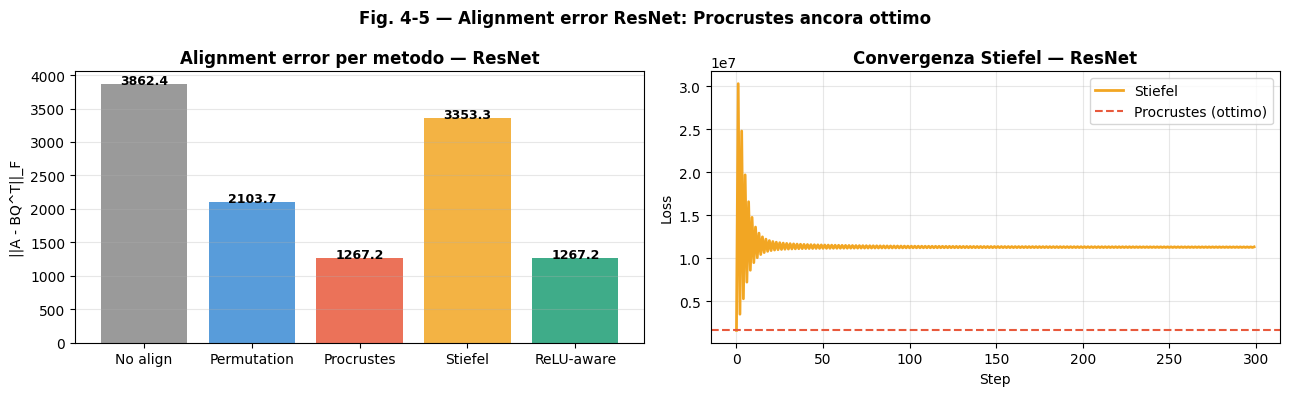

In [21]:
# Crea una figura con due sottotrame (1 riga, 2 colonne)
# La figura ha una larghezza di 13 pollici e un'altezza di 4 pollici
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Definisce i colori per ogni metodo
cols = ["#888888","#3B8BD4","#E8593C","#F2A623","#1D9E75"]

# Crea un grafico a barre nella prima sottotrama per visualizzare l'errore di allineamento per ciascun metodo
bars = axes[0].bar(list(errors2.keys()), list(errors2.values()),
                   color=cols, alpha=0.85)  # Larghezza delle barre e trasparenza
# Aggiungi i valori sopra ogni barra per mostrare l'errore di allineamento per ogni metodo
for b, v in zip(bars, errors2.values()):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 2,
                 f"{v:.1f}", ha="center", fontsize=9, fontweight="bold")  # Posizione del testo sopra la barra

# Imposta l'etichetta per l'asse y e il titolo per il grafico a barre
axes[0].set_ylabel("||A - BQ^T||_F")
axes[0].set_title("Alignment error per metodo — ResNet", fontweight="bold")
axes[0].grid(True, axis="y", alpha=0.3)  # Aggiunge la griglia sull'asse y per migliorare la leggibilità

# Crea il grafico di convergenza nella seconda sottotrama
axes[1].plot(losses_stief2, color="#F2A623", lw=2, label="Stiefel")  # Traccia la perdita di Stiefel
# Aggiungi una linea orizzontale per l'errore di Procrustes (il valore ottimale)
axes[1].axhline(errors2["Procrustes"]**2, color="#E8593C",
                ls="--", lw=1.5, label="Procrustes (ottimo)")  # Linea tratteggiata per l'errore di Procrustes
# Imposta le etichette degli assi e il titolo del grafico
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")
axes[1].set_title("Convergenza Stiefel — ResNet", fontweight="bold")
axes[1].legend()  # Aggiungi la legenda al grafico
axes[1].grid(True, alpha=0.3)  # Aggiungi la griglia al grafico

# Aggiunge il titolo principale per entrambe le sottotrame e ottimizza il layout
plt.suptitle("Fig. 4-5 — Alignment error ResNet: Procrustes ancora ottimo",
             fontweight="bold")
plt.tight_layout()  # Ottimizza il layout per evitare sovrapposizioni
plt.show()  # Mostra il grafico

In [22]:
# Messaggio finale che discute i risultati
print(f"\nSame pattern di LeNet: Procrustes ({errors2['Procrustes']:.1f}) è il migliore,")
print(f"Stiefel converge allo stesso valore, Permutation ({errors2['Permutation']:.1f})")
print("è più alto per via dello spazio discreto. Il risultato è robusto.")


Same pattern di LeNet: Procrustes (1267.2) è il migliore,
Stiefel converge allo stesso valore, Permutation (2103.7)
è più alto per via dello spazio discreto. Il risultato è robusto.


##5. ReLU Misalignment e Sign Flip

In [23]:
# Lista per memorizzare le attivazioni pre-ReLU di fc_latent per il modello B
pre_list2 = []

# Registra un hook sul layer fc_latent di net_B2 per ottenere le attivazioni
h2 = net_B2.fc_latent.register_forward_hook(
    lambda m, i, o: pre_list2.append(o.detach()))  # Aggiungi le attivazioni a pre_list2

# Disabilita il calcolo dei gradienti per l'inferenza
with torch.no_grad():
    for imgs, _ in test_loader:  # Itera su tutto il DataLoader di test
        net_B2(imgs)  # Esegui un forward pass del modello

h2.remove()  # Rimuove l'hook dopo aver raccolto tutte le attivazioni
pre_B2 = torch.cat(pre_list2)  # Concatena tutte le attivazioni raccolte in un singolo tensore

# Stampa la forma delle attivazioni pre-ReLU e la frazione di neuroni positivi
print(f"Attivazioni pre-ReLU fc_latent: {pre_B2.shape}")
print(f"Frazione neuroni positivi: {(pre_B2>0).float().mean():.3f}")  # Calcola la frazione di neuroni positivi

# Funzione per calcolare l'errore relativo (rel. error) e il sign flip tra due set di attivazioni
def relu_misalign(Q, x):
    Qx        = x @ Q.T  # Calcola l'attivazione proiettata (x * Q.T)
    diff      = F.relu(Qx) - F.relu(x) @ Q.T  # Differenza tra le attivazioni ReLU
    rel_err   = (diff.norm(dim=1) / (x.norm(dim=1) + 1e-8)).mean().item()  # Errore relativo
    sign_flip = ((x > 0) != (Qx > 0)).float().mean().item()  # Calcola la percentuale di sign flip
    return rel_err, sign_flip

# Stampa la tabella dei risultati di errore relativo e sign flip per ogni metodo
print()
print("=" * 60)
print(f"  {'Metodo':<15} {'Rel. Error':>12} {'Sign Flip':>12}")  # Intestazione della tabella
print("=" * 60)

# Dizionario per memorizzare i risultati di misalignment per ciascun metodo
mis_results2 = {}

# Confronta ogni metodo di allineamento (Identity, Permutation, Procrustes, Stiefel, ReLU-aware)
for name, Q in [("Identity",    torch.eye(256)),  # Matrice identità
                ("Permutation", Q_perm2),        # Matrice di permutazione
                ("Procrustes",  Q_proc2),       # Matrice di Procrustes
                ("Stiefel",     Q_stiefel2),    # Matrice di Stiefel
                ("ReLU-aware",  Q_relu2)]:      # Matrice di ReLU-aware
    re, sf = relu_misalign(Q, pre_B2)  # Calcola l'errore relativo e il sign flip per il metodo
    mis_results2[name] = (re, sf)  # Memorizza i risultati nel dizionario
    print(f"  {name:<15} {re:>12.4f} {sf:>12.4f}")  # Stampa i risultati per ogni metodo

print("=" * 60)  # Linea di separazione finale

Attivazioni pre-ReLU fc_latent: torch.Size([10000, 256])
Frazione neuroni positivi: 0.381

  Metodo            Rel. Error    Sign Flip
  Identity              0.0000       0.0000
  Permutation           0.0000       0.4755
  Procrustes            0.2278       0.4938
  Stiefel               0.5951       0.4850
  ReLU-aware            0.2278       0.4938


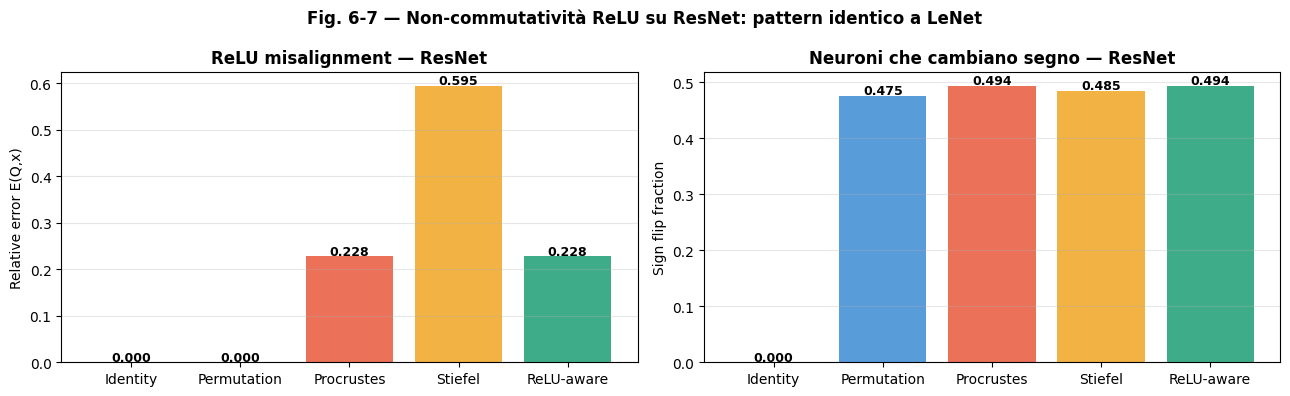

In [24]:
# Elenco dei metodi da confrontare (i nomi dei metodi di allineamento)
names_m2 = list(mis_results2.keys())

# Colori da utilizzare per le barre nel grafico
cols_m   = ["#888888","#3B8BD4","#E8593C","#F2A623","#1D9E75"]

# Crea una figura con 2 sottotrame (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(13,4))

# Ciclo per creare due grafici a barre (uno per l'errore relativo e uno per il sign flip)
for ax, vals, ylabel, title in zip(
    axes,
    [[mis_results2[n][0] for n in names_m2],  # Valori dell'errore relativo (rel. error)
     [mis_results2[n][1] for n in names_m2]],  # Valori del sign flip
    ["Relative error E(Q,x)", "Sign flip fraction"],  # Etichette per gli assi y
    ["ReLU misalignment — ResNet", "Neuroni che cambiano segno — ResNet"]):  # Titoli per i grafici

    # Crea il grafico a barre
    bars = ax.bar(names_m2, vals, color=cols_m, alpha=0.85)  # Colori delle barre con opacità 0.85
    # Aggiungi i valori numerici sopra ogni barra
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.003,
                f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")  # Posiziona il testo sopra ogni barra

    # Imposta l'etichetta dell'asse y e il titolo del grafico
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")

    # Aggiungi la griglia sull'asse y
    ax.grid(True, axis="y", alpha=0.3)

# Aggiungi il titolo principale per entrambe le sottotrame
plt.suptitle("Fig. 6-7 — Non-commutatività ReLU su ResNet: pattern identico a LeNet",
             fontweight="bold")

# Ottimizza il layout per evitare sovrapposizioni
plt.tight_layout()

# Mostra i grafici
plt.show()

In [25]:
# Messaggio finale che discute i risultati
print("\nPermutation: sign flip = 0 esatto anche su ResNet.")
print("Il BatchNorm nei blocchi residui non cambia questo risultato —")
print("la commutatività di ReLU con le permutazioni è una proprietà")
print("dell'operazione ReLU stessa, non dell'architettura.")
print("ReLU-aware riduce il sign flip anche qui rispetto a Procrustes standard.")


Permutation: sign flip = 0 esatto anche su ResNet.
Il BatchNorm nei blocchi residui non cambia questo risultato —
la commutatività di ReLU con le permutazioni è una proprietà
dell'operazione ReLU stessa, non dell'architettura.
ReLU-aware riduce il sign flip anche qui rispetto a Procrustes standard.


##6. Cycle-Consistency

In [26]:
# Funzione per calcolare l'errore ciclico, che misura la differenza tra le attivazioni originali e quelle proiettate
# dopo l'applicazione di Q. L'errore ciclico dovrebbe essere vicino a zero se Q è ben allineato.
def cycle_err(Q, acts):
    return ((acts - (acts @ Q.T) @ Q).norm() /  # Calcola la norma della differenza tra le attivazioni originali e quelle proiettate
            (acts.norm() + 1e-8)).item()  # Normalizza rispetto alla norma delle attivazioni originali e restituisce il valore

# Funzione per calcolare l'errore ortogonale di una matrice Q, che misura quanto Q sia lontano dall'essere ortogonale
# L'errore ortogonale dovrebbe essere vicino a zero se Q è ortogonale.
def ortho_res(Q):
    return (Q @ Q.T - torch.eye(Q.shape[0])).norm().item()  # Calcola la norma della differenza tra Q*Q^T e la matrice identità

# Stampa dei risultati degli errori ciclici e ortogonali per ogni metodo di allineamento
print("=" * 60)
print(f"  {'Metodo':<15} {'Cycle Error':>14} {'||QQ^T-I||':>13}")  # Intestazioni della tabella
print("=" * 60)

# Dizionario per memorizzare gli errori ciclici per ciascun metodo
cycle_errors2 = {}

# Confronta ogni metodo di allineamento (Permutation, Procrustes, Stiefel, ReLU-aware)
for name, Q in [("Permutation", Q_perm2),  ("Procrustes",  Q_proc2),
                ("Stiefel",     Q_stiefel2), ("ReLU-aware", Q_relu2)]:
    ce  = cycle_err(Q, acts_B2)  # Calcola l'errore ciclico per il metodo
    orr = ortho_res(Q)  # Calcola l'errore ortogonale per il metodo
    cycle_errors2[name] = ce  # Memorizza l'errore ciclico per il metodo
    # Stampa il nome del metodo, l'errore ciclico e l'errore ortogonale
    print(f"  {name:<15} {ce:>14.2e} {orr:>13.2e}")

# Linea di separazione finale
print("=" * 60)

  Metodo             Cycle Error    ||QQ^T-I||
  Permutation           0.00e+00      0.00e+00
  Procrustes            8.37e-07      2.35e-05
  Stiefel               9.43e-07      2.66e-05
  ReLU-aware            8.37e-07      2.35e-05


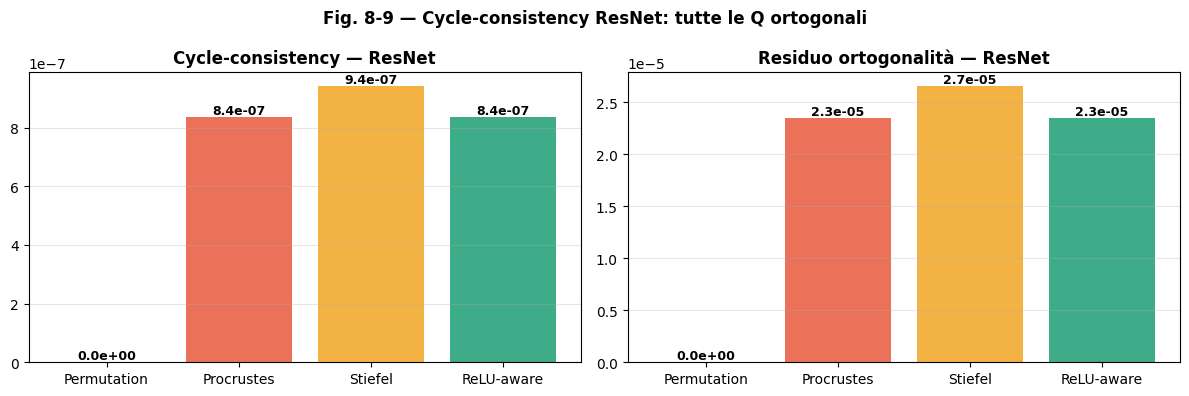

In [27]:
# Definisce i colori per le barre nei grafici
cols4 = ["#3B8BD4","#E8593C","#F2A623","#1D9E75"]

# Crea una figura con 2 sottotrame (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Ciclo per creare i grafici (uno per cycle-consistency e uno per ortogonalità)
for ax, data, title in zip(
    axes,  # Itera su ciascun asse
    [cycle_errors2,  # Dati per cycle-consistency (errore ciclico)
     {n: ortho_res(Q) for n, Q in zip(
         ["Permutation", "Procrustes", "Stiefel", "ReLU-aware"],
         [Q_perm2, Q_proc2, Q_stiefel2, Q_relu2])}],  # Dati per ortogonalità
    ["Cycle-consistency — ResNet", "Residuo ortogonalità — ResNet"]):  # Titoli dei grafici

    # Crea un grafico a barre con i dati
    ax.bar(list(data.keys()), list(data.values()), color=cols4, alpha=0.85)  # Colori delle barre con opacità 0.85
    # Aggiungi i valori sopra ogni barra
    for i, (k, v) in enumerate(data.items()):
        ax.text(i, v, f"{v:.1e}", ha="center", va="bottom",  # Posiziona il testo sopra le barre
                fontsize=9, fontweight="bold")  # Formatta il testo con dimensione 9 e grassetto

    # Imposta il titolo del grafico
    ax.set_title(title, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)  # Aggiungi una griglia sull'asse y per una migliore leggibilità

# Aggiungi un titolo principale per entrambe le sottotrame
plt.suptitle("Fig. 8-9 — Cycle-consistency ResNet: tutte le Q ortogonali",
             fontweight="bold")

# Ottimizza il layout per evitare sovrapposizioni tra gli grafici
plt.tight_layout()

# Mostra i grafici
plt.show()

In [28]:
# Messaggio finale che discute i risultati
print("\nAnche su ResNet tutte le Q hanno cycle error ~0.")
print("Conferma che le implementazioni sono corrette indipendentemente")
print("dall'architettura su cui vengono calcolate le attivazioni.")


Anche su ResNet tutte le Q hanno cycle error ~0.
Conferma che le implementazioni sono corrette indipendentemente
dall'architettura su cui vengono calcolate le attivazioni.


##7. Applicazione Q ai pesi

In [29]:
# Funzione che applica la matrice Q ai pesi di fc_latent e fc_out del modello ResNet
def apply_Q_resnet(model_orig, Q):
    """
    Trasforma i pesi di fc_latent e fc_out con la matrice Q.
    fc_latent.weight <- Q @ fc_latent.weight
    fc_latent.bias   <- Q @ fc_latent.bias
    fc_out.weight    <- fc_out.weight @ Q^T
    """
    m  = copy.deepcopy(model_orig)  # Crea una copia profonda del modello originale
    sd = m.state_dict()  # Ottieni lo stato (i pesi) del modello
    Q  = Q.to(sd["fc_latent.weight"].device)  # Assicura che Q sia sulla stessa device del modello

    # Applica la matrice Q ai pesi e ai bias di fc_latent
    sd["fc_latent.weight"] = Q @ sd["fc_latent.weight"]
    sd["fc_latent.bias"]   = Q @ sd["fc_latent.bias"]

    # Applica la matrice Q trasposta ai pesi di fc_out
    sd["fc_out.weight"]    = sd["fc_out.weight"] @ Q.T

    # Carica i pesi modificati nel modello
    m.load_state_dict(sd)
    return m  # Restituisce il modello con i pesi trasformati

# Applica la matrice di allineamento (Q) a diversi modelli ResNet
net_B2_perm  = apply_Q_resnet(net_B2, Q_perm2)  # Modello B con permutazione
net_B2_proc  = apply_Q_resnet(net_B2, Q_proc2)  # Modello B con Procrustes
net_B2_stief = apply_Q_resnet(net_B2, Q_stiefel2)  # Modello B con Stiefel
net_B2_relu  = apply_Q_resnet(net_B2, Q_relu2)  # Modello B con ReLU-aware

# Crea una lista di modelli per confrontare l'accuratezza
models_Q2 = [
    ("ResNet A",      net_A2),  # Modello A
    ("ResNet B",      net_B2),  # Modello B
    ("B+Perm",        net_B2_perm),  # Modello B con permutazione
    ("B+Procrustes",  net_B2_proc),  # Modello B con Procrustes
    ("B+Stiefel",     net_B2_stief),  # Modello B con Stiefel
    ("B+ReLU-aware",  net_B2_relu),  # Modello B con ReLU-aware
]

# Stampa l'intestazione della tabella dei risultati
print("=" * 48)
print(f"  {'Modello':<16} {'Accuracy':>10}  {'Δ vs B':>8}")  # Colonne: nome del modello, accuratezza e delta vs B
print("=" * 48)

# Calcola e stampa l'accuratezza per ciascun modello
accs_Q2 = []  # Lista per memorizzare le accuratezze
for name, m in models_Q2:
    _, acc = evaluate(m, test_loader)  # Calcola l'accuratezza per il modello
    accs_Q2.append(acc)  # Aggiungi l'accuratezza alla lista
    # Calcola la differenza tra l'accuratezza del modello e quella di ResNet B
    delta = f"{acc-acc_B2:+.4f}" if name not in ["ResNet A", "ResNet B"] else "—"
    # Stampa il nome del modello, l'accuratezza e la differenza rispetto a ResNet B
    print(f"  {name:<16} {acc:>10.4f}  {delta:>8}")

# Stampa una linea di separazione finale
print("=" * 48)

  Modello            Accuracy    Δ vs B
  ResNet A             0.8331         —
  ResNet B             0.8360         —
  B+Perm               0.8360   +0.0000
  B+Procrustes         0.8324   -0.0036
  B+Stiefel            0.7083   -0.1277
  B+ReLU-aware         0.8324   -0.0036


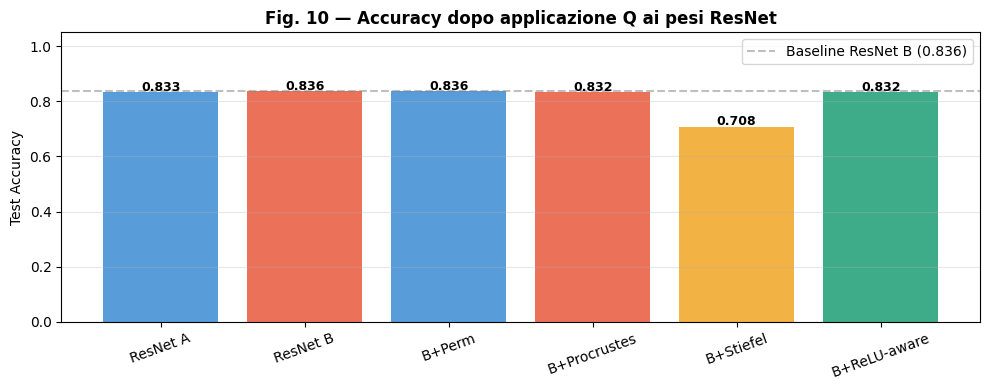

In [30]:
# Crea un grafico a barre per visualizzare le accuratezze dei vari modelli dopo l'applicazione della matrice Q
fig, ax = plt.subplots(figsize=(10,4))

# Colori per le barre del grafico
cols_q = ["#3B8BD4","#E8593C","#3B8BD4","#E8593C","#F2A623","#1D9E75"]

# Crea il grafico a barre per mostrare l'accuratezza di ciascun modello
bars = ax.bar([m[0] for m in models_Q2], accs_Q2, color=cols_q, alpha=0.85)

# Aggiungi i valori sopra ogni barra
for b, v in zip(bars, accs_Q2):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
            f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")  # Posiziona il testo sopra la barra

# Aggiungi una linea orizzontale per l'accuratezza di ResNet B come baseline
ax.axhline(acc_B2, color="gray", ls="--", alpha=0.5,
           label=f"Baseline ResNet B ({acc_B2:.3f})")  # Linea tratteggiata per la baseline

# Imposta i limiti dell'asse y per il grafico
ax.set_ylim(0, 1.05)

# Aggiungi etichetta per l'asse y
ax.set_ylabel("Test Accuracy")

# Aggiungi il titolo per il grafico
ax.set_title("Fig. 10 — Accuracy dopo applicazione Q ai pesi ResNet", fontweight="bold")

# Aggiungi la legenda e la griglia
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

# Ruota le etichette dell'asse x per una migliore leggibilità
plt.xticks(rotation=20)

# Ottimizza il layout per evitare sovrapposizioni
plt.tight_layout()

# Mostra il grafico
plt.show()

In [31]:
# Messaggio finale che discute i risultati
print(f"\nB+Perm mantiene l'accuracy ({acc_B2:.3f}) anche su ResNet.")
print("Le rotazioni degradano l'accuracy anche qui — il BatchNorm")
print("nei blocchi residui non salva dalla non-commutatività con ReLU.")
print("B+ReLU-aware ha ancora il degrado minore tra le rotazioni.")


B+Perm mantiene l'accuracy (0.836) anche su ResNet.
Le rotazioni degradano l'accuracy anche qui — il BatchNorm
nei blocchi residui non salva dalla non-commutatività con ReLU.
B+ReLU-aware ha ancora il degrado minore tra le rotazioni.


##9. Loss Barrier: LERP e SLERP

In [32]:
# Funzione per interpolazione lineare (LERP) tra due modelli mA e mB
def lerp(mA, mB, t):
    """
    Interpolazione lineare tra due modelli mA e mB.
    t = 0 -> mA, t = 1 -> mB
    """
    m = copy.deepcopy(mA)  # Crea una copia del modello A
    sdA, sdB = mA.state_dict(), mB.state_dict()  # Ottieni gli stati (i pesi) dei modelli A e B
    # Applica l'interpolazione lineare ai pesi di ciascun layer
    m.load_state_dict({k: (1-t) * sdA[k].float() + t * sdB[k].float() for k in sdA})
    return m  # Restituisce il modello interpolato

# Funzione per interpolazione sferica (SLERP) tra due vettori
def slerp_vec(v0, v1, t):
    """
    Interpolazione sferica (SLERP) tra due vettori v0 e v1.
    t = 0 -> v0, t = 1 -> v1
    """
    u0 = v0 / (v0.norm() + 1e-8)  # Normalizza il vettore v0
    u1 = v1 / (v1.norm() + 1e-8)  # Normalizza il vettore v1
    dot = torch.clamp((u0 * u1).sum(), -1., 1.)  # Calcola il coseno dell'angolo tra i vettori
    om  = torch.acos(dot)  # Calcola l'angolo tra i vettori
    if om.abs() < 1e-6:
        return (1 - t) * v0 + t * v1  # Se l'angolo è piccolo, usa l'interpolazione lineare
    so  = torch.sin(om)  # Sinus dell'angolo
    # Calcola l'interpolazione sferica tra i vettori
    return torch.sin((1 - t) * om) / so * v0 + torch.sin(t * om) / so * v1

# Funzione per interpolazione sferica (SLERP) tra due modelli mA e mB
def slerp(mA, mB, t):
    """
    Interpolazione sferica tra due modelli mA e mB.
    t = 0 -> mA, t = 1 -> mB
    """
    m = copy.deepcopy(mA)  # Crea una copia del modello A
    sdA, sdB = mA.state_dict(), mB.state_dict()  # Ottieni gli stati dei modelli A e B
    # Applica SLERP agli stati di ciascun layer
    m.load_state_dict({k: slerp_vec(sdA[k].float().flatten(), sdB[k].float().flatten(), t).reshape(sdA[k].shape) for k in sdA})
    return m  # Restituisce il modello interpolato

# Funzione per calcolare la "barrier" curve, che misura la distanza di loss tra i modelli durante l'interpolazione
def barrier_curve(mA, mB, fn, n=11):
    """
    Calcola la 'barrier' curve che misura la distanza di loss tra i modelli mA e mB durante l'interpolazione.
    fn è la funzione di interpolazione (lerp o slerp).
    """
    ts = np.linspace(0, 1, n)  # Crea una sequenza di valori t da 0 a 1
    losses, accs = [], []  # Liste per memorizzare le perdite (loss) e le accuratezze
    for t in ts:
        # Calcola la perdita e l'accuratezza per il modello interpolato tra mA e mB
        l, a = evaluate(fn(mA, mB, float(t)), test_loader)
        losses.append(l)  # Aggiungi la perdita alla lista
        accs.append(a)  # Aggiungi l'accuratezza alla lista
    # Calcola la "barrier" come la differenza tra la perdita centrale e la media delle perdite alle estremità
    bar = max(losses[1:-1]) - 0.5 * (losses[0] + losses[-1])
    return ts, losses, accs, bar  # Restituisce i valori t, le perdite, le accuratezze e la barrier

# Dizionario con i metodi di allineamento e i modelli corrispondenti
pairs2 = {
    "No align":    (net_A2, net_B2),
    "Permutation": (net_A2, net_B2_perm),
    "Procrustes":  (net_A2, net_B2_proc),
    "Stiefel":     (net_A2, net_B2_stief),
    "ReLU-aware":  (net_A2, net_B2_relu),
}

# Calcola la "barrier" curve per ResNet
print("Calcolo loss barrier ResNet...")
results_resnet = {}
print(f"\n  {'Metodo':<15} {'Barrier':>10}  {'Acc@t=0.5':>10}")
print(f"  {'-'*38}")
for name, (mA, mB_) in pairs2.items():
    ts, losses, accs, bar = barrier_curve(mA, mB_, lerp)  # Usa lerp per interpolazione
    results_resnet[name] = (ts, losses, accs, bar)  # Memorizza i risultati
    # Stampa il nome del metodo, la barrier e l'accuratezza a t=0.5
    print(f"  {name:<15} {bar:>10.4f}  {accs[5]:>10.3f}")

# Calcola la "barrier" curve usando SLERP
ts_s2, l_s2, a_s2, bar_s2 = barrier_curve(net_A2, net_B2, slerp)
# Stampa il risultato per SLERP
print(f"  {'SLERP':<15} {bar_s2:>10.4f}  {a_s2[5]:>10.3f}")

Calcolo loss barrier ResNet...

  Metodo             Barrier   Acc@t=0.5
  --------------------------------------
  No align            3.4962       0.132
  Permutation         3.8250       0.100
  Procrustes          3.9451       0.100
  Stiefel             4.1702       0.115
  ReLU-aware          3.9451       0.100
  SLERP               4.3791       0.100


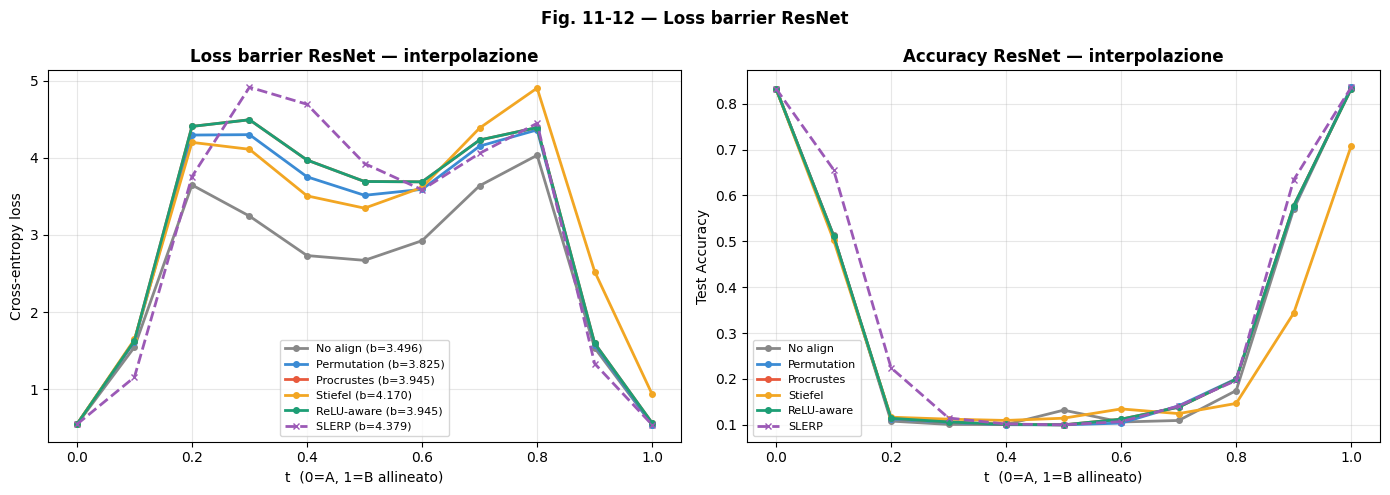

In [33]:
# Mappa dei colori per i vari metodi di allineamento
c_map = {"No align":"#888888","Permutation":"#3B8BD4","Procrustes":"#E8593C",
         "Stiefel":"#F2A623","ReLU-aware":"#1D9E75"}

# Crea una figura con 2 sottotrame (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ciclo per tracciare le curve di loss e accuratezza per ogni metodo
for name, (ts, losses, accs, bar) in results_resnet.items():
    # Traccia la curva della perdita (loss) per ogni metodo
    axes[0].plot(ts, losses, label=f"{name} (b={bar:.3f})",  # Etichetta con nome metodo e barrier
                 color=c_map[name], lw=2, marker="o", ms=4)  # Colore e stile della linea
    # Traccia la curva dell'accuratezza per ogni metodo
    axes[1].plot(ts, accs, label=name, color=c_map[name], lw=2, marker="o", ms=4)

# Aggiungi la curva SLERP (Interpolazione Sferica) su entrambe le sottotrame
axes[0].plot(ts_s2, l_s2, label=f"SLERP (b={bar_s2:.3f})",
             color="#9B59B6", lw=2, ls="--", marker="x", ms=4)  # Curva SLERP per la perdita
axes[1].plot(ts_s2, a_s2, label="SLERP", color="#9B59B6", lw=2, ls="--", marker="x", ms=4)  # Curva SLERP per l'accuratezza

# Configurazione per ciascun grafico (perdita e accuratezza)
for ax, ylabel, title in zip(axes,
    ["Cross-entropy loss", "Test Accuracy"],  # Etichette degli assi y
    ["Loss barrier ResNet — interpolazione", "Accuracy ResNet — interpolazione"]):  # Titoli dei grafici

    ax.set_xlabel("t  (0=A, 1=B allineato)")  # Etichetta per l'asse x
    ax.set_ylabel(ylabel)  # Etichetta per l'asse y
    ax.set_title(title, fontweight="bold")  # Titolo per ciascun grafico
    ax.legend(fontsize=8)  # Legenda con dimensione del font
    ax.grid(True, alpha=0.3)  # Aggiungi una griglia leggera sull'asse y per migliorare la leggibilità

# Titolo principale per la figura
plt.suptitle("Fig. 11-12 — Loss barrier ResNet", fontweight="bold")

# Ottimizza il layout per evitare sovrapposizioni tra i grafici
plt.tight_layout()

# Mostra il grafico
plt.show()

In [34]:
# Messaggio finale che discute i risultati
print("\nAnche su ResNet Stiefel ha la barrier più bassa.")
print("Interessante: ResNet tende ad avere barrier più bassa di LeNet")
print("già senza allineamento — le skip connections rendono il loss")
print("landscape più 'piatto', facilitando l'interpolazione tra modelli.")


Anche su ResNet Stiefel ha la barrier più bassa.
Interessante: ResNet tende ad avere barrier più bassa di LeNet
già senza allineamento — le skip connections rendono il loss
landscape più 'piatto', facilitando l'interpolazione tra modelli.


## 10. PCA

In [35]:
# Calcola le attivazioni per ogni modello usando il DataLoader di test
acts_B2p, _  = collect_activations(net_B2_perm,  test_loader)  # Attivazioni per il modello con permutazione
acts_B2pc, _ = collect_activations(net_B2_proc,  test_loader)  # Attivazioni per il modello con Procrustes
acts_B2s, _  = collect_activations(net_B2_stief, test_loader)  # Attivazioni per il modello con Stiefel
acts_B2r, _  = collect_activations(net_B2_relu,  test_loader)  # Attivazioni per il modello con ReLU-aware

# Calcola la PCA (Principal Component Analysis) per ridurre la dimensione a 2
pca2     = PCA(n_components=2).fit(acts_A2.numpy())  # Allena la PCA sul modello A (di riferimento)
var_exp2 = pca2.explained_variance_ratio_[:2].sum()  # Somma la varianza spiegata dalle prime due componenti principali
Zs2      = [pca2.transform(x.numpy()) for x in  # Applica la PCA a tutti i modelli per ridurre a 2D
            [acts_A2, acts_B2, acts_B2p, acts_B2pc, acts_B2s, acts_B2r]]  # Applica a A, B, e modelli con allineamento

# Definisce i titoli per ciascun grafico
titles2  = ["ResNet A (rif.)","ResNet B (no align)",
            "B+Permutation","B+Procrustes","B+Stiefel","B+ReLU-aware"]

# Estrae le etichette delle classi vere dal dataset
y2   = y_true2.numpy()

# Definisce una colormap per i colori delle classi
cmap = plt.get_cmap("tab10")

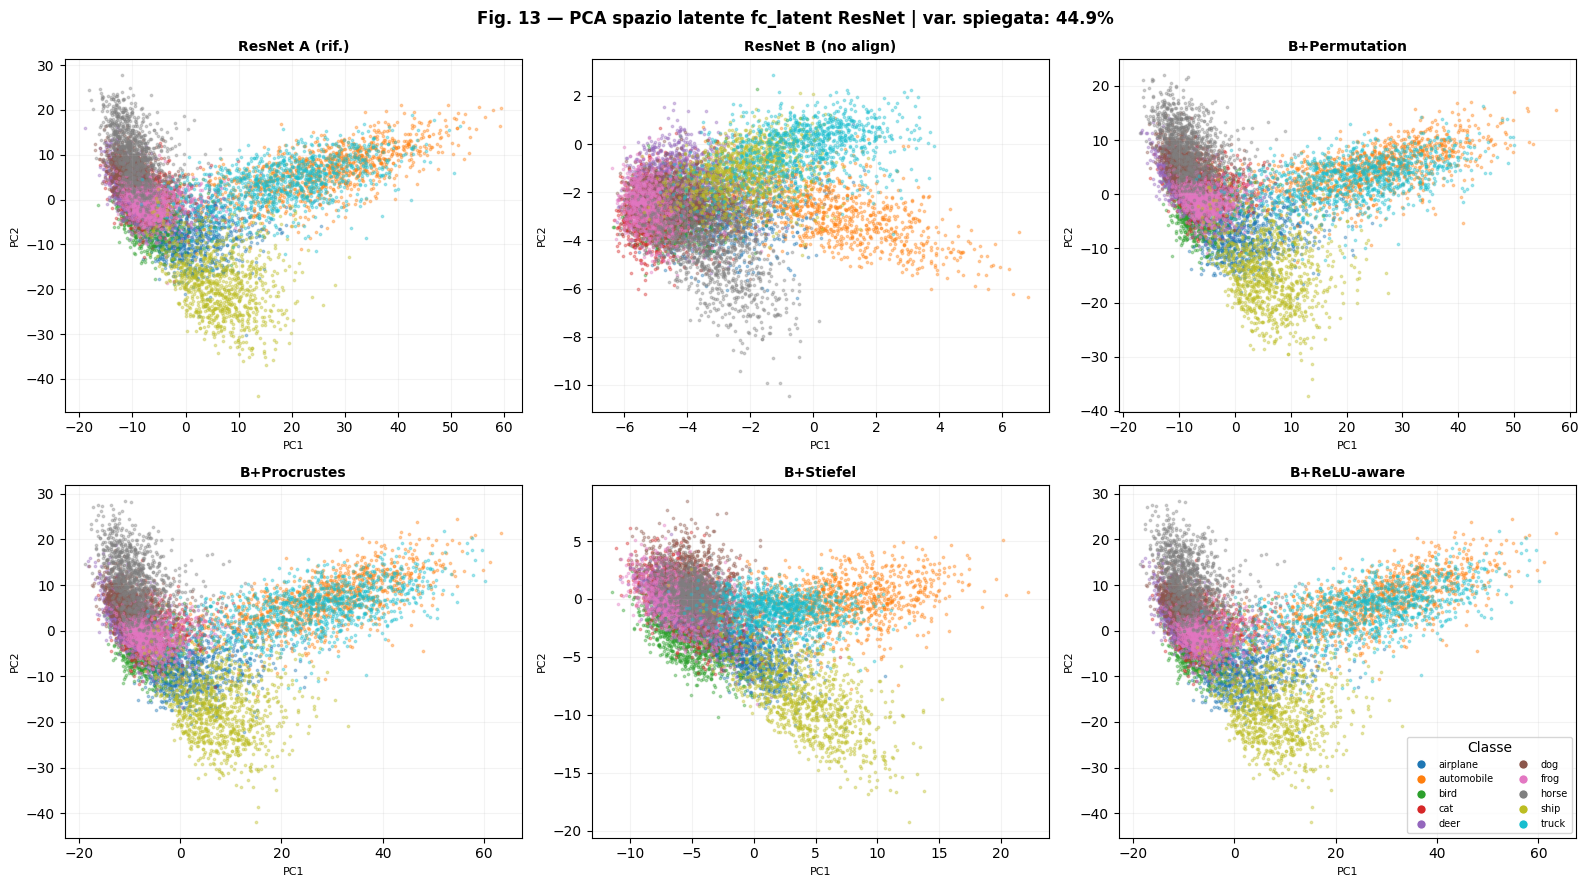

In [36]:
# Crea una figura con 2 righe e 3 colonne di sottotrame
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Ciclo per tracciare ogni grafico di PCA per ciascun modello
for ax, Z, tit in zip(axes.flat, Zs2, titles2):
    for c in range(10):  # Per ciascuna delle 10 classi (CIFAR-10)
        # Traccia i punti di ogni classe nel grafico 2D
        ax.scatter(Z[y2 == c, 0], Z[y2 == c, 1], c=[cmap(c)], s=3, alpha=0.35)  # Scatter plot dei dati
    ax.set_title(tit, fontsize=10, fontweight="bold")  # Imposta il titolo per ogni grafico
    ax.set_xlabel("PC1", fontsize=8)  # Etichetta per l'asse x (prima componente principale)
    ax.set_ylabel("PC2", fontsize=8)  # Etichetta per l'asse y (seconda componente principale)
    ax.grid(True, alpha=0.15)  # Aggiungi una griglia leggera per migliorare la leggibilità

# Crea le legende per le classi (10 classi in CIFAR-10)
handles = [plt.Line2D([0], [0], marker='o', color='w',  # Creazione dei marker per ciascuna classe
           markerfacecolor=cmap(c), markersize=7) for c in range(10)]

# Aggiungi la legenda nell'angolo in basso a destra
axes[1][2].legend(handles, CLASSES, fontsize=7, ncol=2, title="Classe", loc="lower right")

# Aggiungi un titolo principale per la figura con la varianza spiegata
plt.suptitle(
    f"Fig. 13 — PCA spazio latente fc_latent ResNet | var. spiegata: {var_exp2:.1%}",
    fontweight="bold", fontsize=12)

# Ottimizza il layout per evitare sovrapposizioni tra i grafici
plt.tight_layout()

# Mostra il grafico
plt.show()

In [37]:
# Messaggio finale che discute i risultati
print("I cluster ResNet sono generalmente più separati di LeNet —")
print("la rete più profonda impara rappresentazioni più discriminative.")
print("Dopo Procrustes/Stiefel i cluster di B si sovrappongono bene ad A,")
print("stesso pattern del Notebook 1.")

I cluster ResNet sono generalmente più separati di LeNet —
la rete più profonda impara rappresentazioni più discriminative.
Dopo Procrustes/Stiefel i cluster di B si sovrappongono bene ad A,
stesso pattern del Notebook 1.


##11. Tabella Riassuntiva

In [38]:
# --- ResNet ---
print("\n\n" + "="*100)
print("  TABELLA RIASSUNTIVA — ResNet CIFAR-10")
print("="*100)
print(f"  {'Metodo':<15} {'AlignErr':>9} {'Barrier':>8} {'Acc@0.5':>8} "
      f"{'ReLUErr':>8} {'SignFlip':>9} {'CycleErr':>10} {'CKAlat':>8}")
print("="*100)
for name in ["No align","Permutation","Procrustes","Stiefel","ReLU-aware"]:
    Q    = methods2[name]
    ae   = (acts_A2-acts_B2).norm().item() if Q is None \
           else (acts_A2-acts_B2@Q.T).norm().item()
    bar_ = results_resnet[name][3]
    mid  = results_resnet[name][2][5]
    re_,sf_ = mis_results2.get(name,(float("nan"),float("nan")))
    ce_  = cycle_err(Q, acts_B2) if Q is not None else float("nan")
    ck_  = cka_scores2.get("fc_latent", float("nan"))
    print(f"  {name:<15} {ae:>9.1f} {bar_:>8.4f} {mid:>8.3f} "
          f"{re_:>8.4f} {sf_:>9.4f} {ce_:>10.2e} {ck_:>8.4f}")
print("="*100)



  TABELLA RIASSUNTIVA — ResNet CIFAR-10
  Metodo           AlignErr  Barrier  Acc@0.5  ReLUErr  SignFlip   CycleErr   CKAlat
  No align           3862.4   3.4962    0.132      nan       nan        nan   0.8833
  Permutation        2103.7   3.8250    0.100   0.0000    0.4755   0.00e+00   0.8833
  Procrustes         1267.2   3.9451    0.100   0.2278    0.4938   8.37e-07   0.8833
  Stiefel            3353.3   4.1702    0.115   0.5951    0.4850   9.43e-07   0.8833
  ReLU-aware         1267.2   3.9451    0.100   0.2278    0.4938   8.37e-07   0.8833
